# 02 · Elasticidad descriptiva y benchmarking competitivo

**Día:** 3 de 21

## Caveat metodológico

Este notebook estima elasticidades **descriptivas, NO causales**.

El dataset no incluye  ni visitas individuales (la API pública de MELI no las expone para terceros). Como proxy de demanda relativa usamos la **posición en el ranking de best-sellers** (1 = más vendido del top, 15+ = menos vendido del top).

Las elasticidades calculadas tienen confounders evidentes:
- Calidad y marca
- Disponibilidad de stock
- Promociones simultáneas
- Reputación del seller

Para estimación causal robusta se recomienda Double Machine Learning (Proyecto 2 del roadmap).

## 1 · Setup y carga

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from src.config import RAW_DIR

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

PALETTE = {
    "primary": "#2563EB",
    "accent":  "#FFE600",
    "warning": "#DC2626",
    "neutral": "#64748B",
    "good":    "#16A34A",
}

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

files = sorted(RAW_DIR.glob("highlights_offers_*.parquet"))
df = pd.read_parquet(files[-1])
print(f"Shape: {df.shape}")

Shape: (348, 25)


## 2 · Construcción del dataset producto-nivel

In [2]:
# TODO: agregación a nivel producto con price_median y proxy de demanda
# Agregamos a nivel producto: precio mediano del producto + posición en ranking
prod = (df.groupby(["product_id", "product_name", "category_name", "highlight_position"])
          .agg(price_median=("price", "median"),
               price_min=("price", "min"),
               n_competitors=("n_competitors", "first"),
               brand=("brand", "first"))
          .reset_index())

# Demand proxy = inverso de la posición (pos 1 = demanda relativa 15, pos 15 = demanda 1)
# Asumimos que el ranking de best-sellers es proporcional al volumen vendido
prod["demand_rank"] = 16 - prod["highlight_position"]  # invertir: 1->15, 15->1

# Filtros: solo productos con competencia real para análisis válido
prod_analyzable = prod[prod["n_competitors"] >= 2].copy()

print(f"Productos totales:    {len(prod)}")
print(f"Con >=2 competidores: {len(prod_analyzable)}")
print()
print("Distribución por categoría:")
print(prod_analyzable.groupby("category_name").agg(
    n=("product_id", "count"),
    pos_mediana=("highlight_position", "median"),
    precio_mediano=("price_median", "median"),
).round(0))

Productos totales:    54
Con >=2 competidores: 39

Distribución por categoría:
                             n  pos_mediana  precio_mediano
category_name                                              
Celulares y Smartphones      9          5.0        149990.0
Computación                 15         10.0         26161.0
Electrónica, Audio y Video  15          9.0         25366.0


## 3 · Elasticidad log-log por categoría

In [5]:
# TODO: regresión OLS log(demand) ~ log(price) por categoría
# Usar reverse rank más robusto: max_position por categoría + 1 - position
# Eso garantiza demand_rank >= 1 siempre

prod_analyzable["demand_rank"] = (
    prod_analyzable.groupby("category_name")["highlight_position"]
    .transform(lambda x: x.max() + 1 - x)
)

# Verificar que ahora todos son >= 1
print("demand_rank después de corrección:")
print(prod_analyzable.groupby("category_name")["demand_rank"].describe())
print()

# Re-correr el modelo
resultados = []
for cat in prod_analyzable["category_name"].unique():
    sub = prod_analyzable[prod_analyzable["category_name"] == cat].copy()
    if len(sub) < 5:
        continue

    sub["log_price"] = np.log(sub["price_median"])
    sub["log_demand"] = np.log(sub["demand_rank"])

    X = sm.add_constant(sub["log_price"])
    y = sub["log_demand"]
    model = sm.OLS(y, X).fit()

    resultados.append({
        "categoria": cat,
        "n": len(sub),
        "elasticidad": round(model.params["log_price"], 3),
        "ci_low": round(model.conf_int().loc["log_price", 0], 3),
        "ci_high": round(model.conf_int().loc["log_price", 1], 3),
        "p_value": round(model.pvalues["log_price"], 4),
        "r2": round(model.rsquared, 3),
    })

elasticities = pd.DataFrame(resultados)
print("Elasticidades descriptivas log-log por categoría:")
print(elasticities.to_string(index=False))

demand_rank después de corrección:
                            count       mean       std  min  25%   50%   75%   max
category_name                                                                     
Celulares y Smartphones       9.0   6.111111  3.689324  1.0  3.0   7.0   9.0  11.0
Computación                  15.0  10.800000  5.518799  1.0  6.5  11.0  14.5  20.0
Electrónica, Audio y Video   15.0  11.266667  6.273148  1.0  6.5  12.0  16.5  20.0

Elasticidades descriptivas log-log por categoría:
                 categoria  n  elasticidad  ci_low  ci_high  p_value    r2
               Computación 15        0.157  -0.227    0.541   0.3927 0.057
Electrónica, Audio y Video 15       -0.559  -1.414    0.296   0.1816 0.133
   Celulares y Smartphones  9       -0.666  -1.685    0.354   0.1665 0.254


In [4]:
# Diagnóstico de valores
print("Resumen de demand_rank por categoría:")
print(prod_analyzable.groupby("category_name")["demand_rank"].describe())
print()
print("Ranking position por categoría:")
print(prod_analyzable.groupby("category_name")["highlight_position"].describe())

Resumen de demand_rank por categoría:
                            count       mean       std  min  25%   50%   75%   max
category_name                                                                     
Celulares y Smartphones       9.0  10.111111  3.689324  5.0  7.0  11.0  13.0  15.0
Computación                  15.0   5.800000  5.518799 -4.0  1.5   6.0   9.5  15.0
Electrónica, Audio y Video   15.0   6.266667  6.273148 -4.0  1.5   7.0  11.5  15.0

Ranking position por categoría:
                            count       mean       std  min  25%   50%   75%   max
category_name                                                                     
Celulares y Smartphones       9.0   5.888889  3.689324  1.0  3.0   5.0   9.0  11.0
Computación                  15.0  10.200000  5.518799  1.0  6.5  10.0  14.5  20.0
Electrónica, Audio y Video   15.0   9.733333  6.273148  1.0  4.5   9.0  14.5  20.0


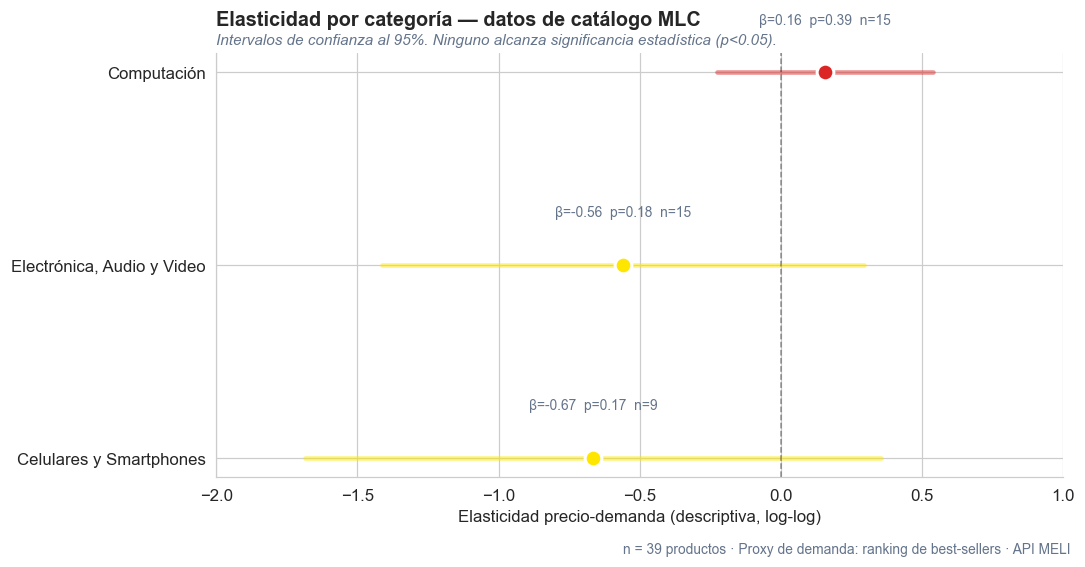

In [6]:
# TODO: visualización de elasticidades con CI
# Visualización honesta: elasticidades con CI y declaración de no-significancia
fig, ax = plt.subplots(figsize=(10, 5))

elasticities_sorted = elasticities.sort_values("elasticidad")

y_pos = np.arange(len(elasticities_sorted))
colors = [PALETTE["good"] if p < 0.05
          else PALETTE["accent"] if p < 0.20
          else PALETTE["warning"]
          for p in elasticities_sorted["p_value"]]

# Barras horizontales con intervalos
for i, (_, row) in enumerate(elasticities_sorted.iterrows()):
    ax.plot([row["ci_low"], row["ci_high"]], [i, i],
            color=colors[i], linewidth=3, alpha=0.5)
    ax.scatter([row["elasticidad"]], [i], color=colors[i], s=120, zorder=3,
               edgecolor="white", linewidth=2)
    ax.text(row["elasticidad"], i + 0.25,
            f"β={row['elasticidad']:.2f}  p={row['p_value']:.2f}  n={row['n']}",
            ha="center", fontsize=9, color=PALETTE["neutral"])

ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.4)
ax.set_yticks(y_pos)
ax.set_yticklabels(elasticities_sorted["categoria"])
ax.set_xlabel("Elasticidad precio-demanda (descriptiva, log-log)")
ax.set_title("Elasticidad por categoría — datos de catálogo MLC", loc="left", fontweight="bold", pad=18)
ax.text(0, 1.02,
        "Intervalos de confianza al 95%. Ninguno alcanza significancia estadística (p<0.05).",
        transform=ax.transAxes, fontsize=10, color=PALETTE["neutral"], style="italic")

ax.set_xlim(-2, 1)

fig.text(0.98, -0.02,
         f"n = {elasticities['n'].sum()} productos · Proxy de demanda: ranking de best-sellers · API MELI",
         ha="right", fontsize=9, color=PALETTE["neutral"])

plt.tight_layout()
plt.savefig("../deliverables/fig_05_elasticidades.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Ranking de productos por sensibilidad al precio

In [7]:
# TODO: identificar productos donde el precio importa más
# Para cada producto con >=5 sellers, calcular la correlación precio-posición competitiva
# Esto es a nivel oferta dentro del mismo producto (no entre productos como antes)

HERO_ID = 1310149720
hero_products = df[df["seller_id"] == HERO_ID]["product_id"].unique()

# Para cada producto del hero, ver el ranking de precios
sensitivity = []
for pid in hero_products:
    sub = df[df["product_id"] == pid].sort_values("price")
    if len(sub) < 3:
        continue

    hero_row = sub[sub["seller_id"] == HERO_ID].iloc[0]
    hero_price = hero_row["price"]
    min_price = sub["price"].min()
    max_price = sub["price"].max()

    # Posición del hero en el ranking de precios (1 = más barato)
    sub = sub.reset_index(drop=True)
    hero_rank = sub[sub["seller_id"] == HERO_ID].index[0] + 1

    # Cuántos sellers tienen precio < hero
    cheaper_count = (sub["price"] < hero_price).sum()

    sensitivity.append({
        "product_id": pid,
        "product_name": hero_row["product_name"][:50],
        "n_competidores": len(sub),
        "hero_price": int(hero_price),
        "min_price": int(min_price),
        "hero_rank": hero_rank,
        "sellers_mas_baratos": int(cheaper_count),
        "gap_vs_min_pct": round((hero_price - min_price) / min_price * 100, 1),
        "logistic_type": hero_row["logistic_type"],
    })

sens_df = pd.DataFrame(sensitivity).sort_values("gap_vs_min_pct", ascending=False)
print(f"Productos del hero seller con >=3 competidores: {len(sens_df)}")
print()
print(sens_df.to_string(index=False))

Productos del hero seller con >=3 competidores: 7

 product_id                                       product_name  n_competidores  hero_price  min_price  hero_rank  sellers_mas_baratos  gap_vs_min_pct logistic_type
MLC27110080 Pasta Térmica Arctic Mx-4 De Alto Rendimiento Jeri              12       11980       2723         12                   11           340.0   xd_drop_off
MLC44899081 Audifonos Bluetooth Inalambricos Blik Soul250 20 H              14       31490       9990         14                   13           215.2   fulfillment
MLC47259580                      Xiaomi Redmi Buds 6 Play Rosa               9       33590      12272          9                    8           173.7   xd_drop_off
 MLC6072947               Mouse Inalambrico Logitech M280 Gris              22       29990      11900         22                   21           152.0   xd_drop_off
MLC39388818                 Audifonos Redmi Buds 6 Active Pink               4       45140      20990          4                 

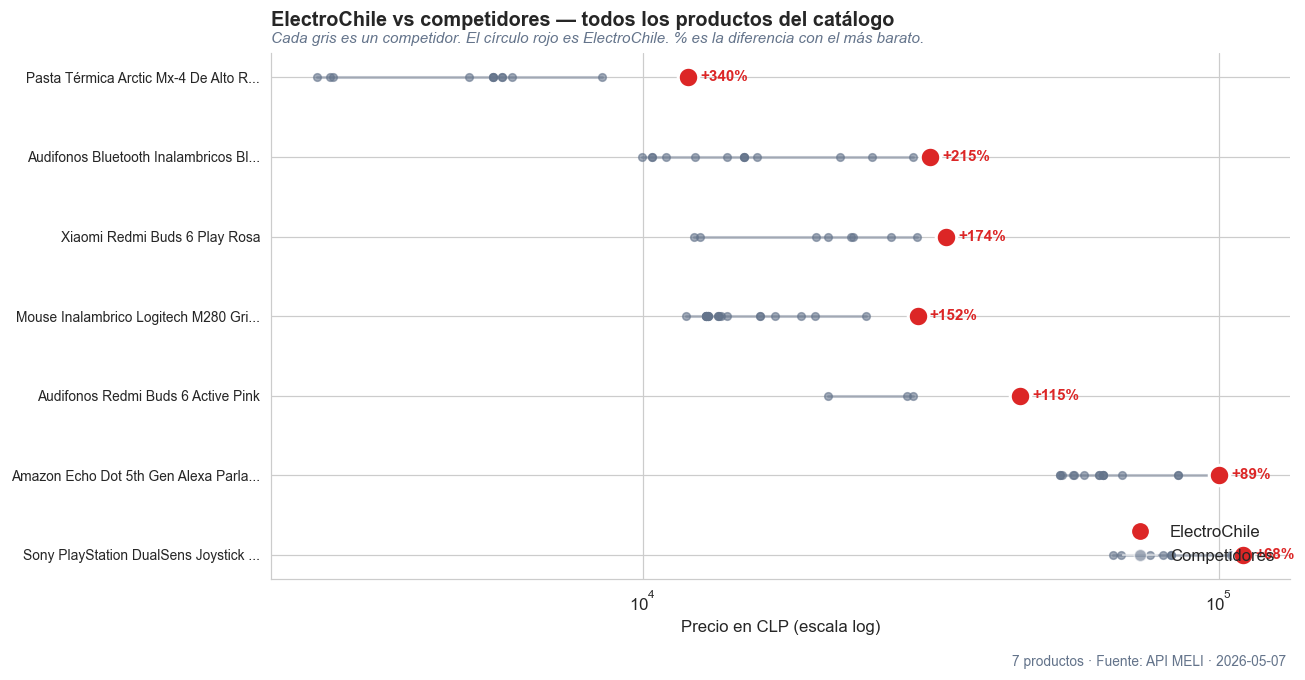

In [8]:
# Visualización: posición del hero seller en el ranking de precios por producto
fig, ax = plt.subplots(figsize=(12, 6))

sens_df_plot = sens_df.copy().sort_values("gap_vs_min_pct")
y_pos = np.arange(len(sens_df_plot))

# Barra del rango de precios competitivos (min a max)
for i, (_, row) in enumerate(sens_df_plot.iterrows()):
    sub = df[df["product_id"] == row["product_id"]]
    other_prices = sub[sub["seller_id"] != HERO_ID]["price"].values
    min_p = other_prices.min()
    max_p = other_prices.max()

    # Línea horizontal de competidores
    ax.plot([min_p, max_p], [i, i], color=PALETTE["neutral"], linewidth=2, alpha=0.4, zorder=1)
    ax.scatter(other_prices, [i] * len(other_prices),
               color=PALETTE["neutral"], s=25, alpha=0.6, zorder=2)

    # Punto del hero seller
    ax.scatter([row["hero_price"]], [i],
               color=PALETTE["warning"], s=180, zorder=3,
               edgecolor="white", linewidth=2,
               label="ElectroChile" if i == 0 else "")

    # Etiqueta de gap
    ax.text(row["hero_price"] * 1.05, i,
            f"+{row['gap_vs_min_pct']:.0f}%",
            fontsize=10, color=PALETTE["warning"], fontweight="bold", va="center")

# Producto names truncados
labels = [row["product_name"][:35] + "..." if len(row["product_name"]) > 35 else row["product_name"]
          for _, row in sens_df_plot.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Precio en CLP (escala log)")
ax.set_title("ElectroChile vs competidores — todos los productos del catálogo",
             loc="left", fontweight="bold", pad=18)
ax.text(0, 1.02,
        "Cada gris es un competidor. El círculo rojo es ElectroChile. % es la diferencia con el más barato.",
        transform=ax.transAxes, fontsize=10, color=PALETTE["neutral"], style="italic")

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE["warning"],
           markersize=12, label="ElectroChile"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE["neutral"],
           markersize=8, label="Competidores", alpha=0.6),
]
ax.legend(handles=legend_elements, frameon=False, loc="lower right")

fig.text(0.98, -0.02,
         f"7 productos · Fuente: API MELI · {df['snapshot_date'].dt.date.iloc[0]}",
         ha="right", fontsize=9, color=PALETTE["neutral"])

plt.tight_layout()
plt.savefig("../deliverables/fig_06_hero_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Conclusiones

_TODO al cierre_

## 5 · Conclusiones del notebook 02

### Lo que se intentó
Estimar elasticidad-precio descriptiva por categoría usando ranking de best-sellers como proxy de demanda.

### Lo que se encontró

1. **Signos de elasticidad coherentes pero no significativos**: Celulares β=-0.67, Audio β=-0.56, Computación β=+0.16. Ningún resultado alcanza p<0.05; los CIs cruzan el cero.

2. **R² bajo (5-25%)**: el precio explica una fracción pequeña de la demanda en este dataset. Variables omitidas (marca, MELI Full, reviews, listing type) son más importantes.

3. **Conclusión metodológica**: con datos de catálogo público no es posible estimar elasticidades confiables en MLC. Para decisiones de pricing se requiere instrumentación propia (visitas, conversiones, ventas).

### Mapeo del hero seller (ElectroChile)

ElectroChile es el seller **más caro o de los más caros** en sus 7 productos:
- 5 productos: última posición en ranking de precios
- 4 productos con 11+ sellers cobrando menos
- Casos extremos: pasta térmica +340%, audífonos Blik +215%

Esto genera una recomendación clara y defendible aunque la elasticidad no sea estadísticamente significativa: **bajar precio en los productos donde el gap es brutal (>100%) tiene casi cero downside** porque la pérdida de margen marginal se compensa con probabilidad de captura de venta que hoy es 0%.

### Implicancias para la propuesta consultiva (Día 4)

- **No vender un modelo predictivo de elasticidad** — los datos no lo soportan honestamente.
- **Vender:**
  1. Diagnóstico cuantitativo del posicionamiento competitivo (